# Cyber Finance AI Forecasting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, LinearRegression
import lightgbm as lgb
import xgboost as xgb
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap

### Data processing 

In [3]:

def load_cyber_data(file_path):
    try:
        cyber_df = pd.read_csv(file_path)
        try:
            cyber_df['AttackDate'] = pd.to_datetime(cyber_df['AttackDate'], dayfirst=True, errors='coerce')
        except:
            try:
                cyber_df['AttackDate'] = pd.to_datetime(cyber_df['AttackDate'], format='%d/%m/%Y %H:%M', errors='coerce')
            except:
                cyber_df['AttackDate'] = pd.to_datetime(cyber_df['AttackDate'], format='mixed', dayfirst=True, errors='coerce')
        cyber_df = cyber_df.dropna(subset=['AttackDate'])
        numeric_cols = ['Spam', 'Ransomware', 'Local Infection', 'Exploit', 
                       'Malicious Mail', 'Network Attack', 'On Demand Scan', 'Web Threat']
        for col in numeric_cols:
            if col in cyber_df.columns:
                cyber_df[col] = pd.to_numeric(cyber_df[col], errors='coerce')
        cyber_df = cyber_df.fillna(0)
        cyber_df['ThreatScore'] = (
            cyber_df['Spam'] * 0.1 + cyber_df['Ransomware'] * 0.3 +
            cyber_df['Local Infection'] * 0.2 + cyber_df['Exploit'] * 0.25 +
            cyber_df['Malicious Mail'] * 0.15 + cyber_df['Network Attack'] * 0.3 +
            cyber_df['On Demand Scan'] * 0.1 + cyber_df['Web Threat'] * 0.2
        )
        cyber_agg = cyber_df.groupby('AttackDate').agg({
            'ThreatScore': ['mean', 'max', 'std'],
            'Ransomware': ['mean', 'max', 'count'],
            'Network Attack': ['mean', 'max'],
            'Exploit': ['mean', 'max'],
            'Malicious Mail': ['mean', 'max']
        }).reset_index()
        cyber_agg.columns = ['Date'] + [f"{col[0]}_{col[1]}" for col in cyber_agg.columns[1:]]
        return cyber_agg
    except Exception as e:
        print(f"Error loading cyber data: {e}")
        return None

In [4]:
def load_finance_data(file_path):
    try:
        finance_df = pd.read_csv(file_path)
        try:
            finance_df['observation_date'] = pd.to_datetime(finance_df['observation_date'], errors='coerce')
        except:
            try:
                finance_df['observation_date'] = pd.to_datetime(finance_df['observation_date'], dayfirst=True, errors='coerce')
            except:
                finance_df['observation_date'] = pd.to_datetime(finance_df['observation_date'], format='mixed', errors='coerce')
        finance_df = finance_df.dropna(subset=['observation_date'])
        finance_df['STLFSI4'] = pd.to_numeric(finance_df['STLFSI4'], errors='coerce')
        finance_df = finance_df.rename(columns={'observation_date': 'Date', 'STLFSI4': 'StressIndex'})
        finance_df['StressIndex_MA_7'] = finance_df['StressIndex'].rolling(window=7).mean()
        finance_df['StressIndex_MA_30'] = finance_df['StressIndex'].rolling(window=30).mean()
        finance_df['StressIndex_Volatility'] = finance_df['StressIndex'].rolling(window=7).std()
        finance_df['StressIndex_Return'] = finance_df['StressIndex'].pct_change()
        finance_df['StressIndex_High_Risk'] = (finance_df['StressIndex'] > 0.5).astype(int)
        for lag in [1, 3, 7]:
            finance_df[f'StressIndex_Lag_{lag}'] = finance_df['StressIndex'].shift(lag)
        return finance_df
    except Exception as e:
        print(f"Error loading finance data: {e}")
        return None

### Temporal alignment 

In [5]:
# Temporal alignment function
def temporal_alignment(cyber_df, finance_df):
    try:
        start_date = max(cyber_df['Date'].min(), finance_df['Date'].min())
        end_date = min(cyber_df['Date'].max(), finance_df['Date'].max())
        date_range = pd.date_range(start=start_date, end=end_date, freq='D')
        aligned_df = pd.DataFrame({'Date': date_range})
        aligned_df = aligned_df.merge(cyber_df, on='Date', how='left')
        aligned_df = aligned_df.merge(finance_df, on='Date', how='left')
        cyber_cols = [col for col in aligned_df.columns if 'Threat' in col or 'Ransomware' in col or 'Network' in col or 'Exploit' in col or 'Malicious' in col]
        aligned_df[cyber_cols] = aligned_df[cyber_cols].ffill().fillna(0)
        finance_cols = [col for col in aligned_df.columns if 'StressIndex' in col]
        aligned_df[finance_cols] = aligned_df[finance_cols].interpolate(method='linear').bfill().fillna(0)
        if 'ThreatScore_mean' in aligned_df.columns and 'StressIndex' in aligned_df.columns:
            aligned_df['ThreatScore_StressIndex_Interaction'] = aligned_df['ThreatScore_mean'] * aligned_df['StressIndex']
        return aligned_df
    except Exception as e:
        print(f"Error in temporal alignment: {e}")
        return None

### Time series sequences

In [6]:
def create_sequences(data, seq_length=30, target_col='StressIndex'):
    feature_cols = [col for col in data.columns if col not in ['Date', target_col]]
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[feature_cols].iloc[i:i+seq_length].values)
        y.append(data[target_col].iloc[i+seq_length])
    return np.array(X), np.array(y), feature_cols

### Neural network models

In [7]:

def create_dual_stream_lstm(cyber_input_dim, finance_input_dim, hidden_dim=128):
    class DualStreamLSTM(nn.Module):
        def __init__(self, cyber_input_dim, finance_input_dim, hidden_dim):
            super(DualStreamLSTM, self).__init__()
            self.cyber_lstm = nn.LSTM(cyber_input_dim, hidden_dim//2, batch_first=True, num_layers=2, dropout=0.3)
            self.finance_lstm = nn.LSTM(finance_input_dim, hidden_dim//2, batch_first=True, num_layers=2, dropout=0.3)
            self.attention = nn.Linear(hidden_dim, 1)  # Attention for dynamic weighting
            self.softmax = nn.Softmax(dim=1)
            self.dropout = nn.Dropout(0.3)
            self.fc1 = nn.Linear(hidden_dim, 64)
            self.fc2 = nn.Linear(64, 1)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            cyber_out, _ = self.cyber_lstm(x)
            finance_out, _ = self.finance_lstm(x)
            combined = torch.cat([cyber_out, finance_out], dim=2)  # Concatenate along feature dimension
            attention_weights = self.softmax(self.attention(combined))  # Compute attention weights
            weighted_combined = torch.sum(combined * attention_weights, dim=1)  # Apply attention
            out = self.dropout(weighted_combined)
            out = self.fc1(out)
            out = self.relu(out)
            out = self.dropout(out)
            out = self.fc2(out)
            return out, attention_weights  # Return attention weights for visualization
    
    return DualStreamLSTM(cyber_input_dim, finance_input_dim, hidden_dim)

###  Temporal fusion transformer

In [ ]:
def create_temporal_fusion_transformer(input_dim, seq_length=30, hidden_dim=256):
    class TemporalFusionTransformer(nn.Module):
        def __init__(self, input_dim, seq_length, hidden_dim):
            super(TemporalFusionTransformer, self).__init__()
            self.input_projection = nn.Linear(input_dim, hidden_dim)
            self.positional_encoding = nn.Parameter(torch.randn(seq_length, hidden_dim))
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=hidden_dim, nhead=8, dim_feedforward=hidden_dim*4, 
                dropout=0.2, batch_first=True
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)
            self.gate = nn.Linear(hidden_dim, hidden_dim)
            self.sigmoid = nn.Sigmoid()
            self.attention = nn.Linear(hidden_dim, 1) 
            self.softmax = nn.Softmax(dim=1)
            self.fc1 = nn.Linear(hidden_dim, 128)
            self.fc2 = nn.Linear(128, 1)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.2)
            
        def forward(self, x):
            x = self.input_projection(x)
            x = x + self.positional_encoding.unsqueeze(0)
            x = self.transformer(x)
            gate = self.sigmoid(self.gate(x))
            x = x * gate
            attention_weights = self.softmax(self.attention(x))
            x = x[:, -1, :]
            x = self.dropout(x)
            x = self.fc1(x)
            x = self.relu(x)
            x = self.dropout(x)
            x = self.fc2(x)
            return x, attention_weights  
    
    return TemporalFusionTransformer(input_dim, seq_length, hidden_dim)

### Gru attention

In [ ]:


def create_gru_attention(input_dim, hidden_dim=128):
    class GRUAttention(nn.Module):
        def __init__(self, input_dim, hidden_dim):
            super(GRUAttention, self).__init__()
            self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
            self.attention = nn.Linear(hidden_dim * 2, 1)
            self.softmax = nn.Softmax(dim=1)
            self.dropout = nn.Dropout(0.3)
            self.fc1 = nn.Linear(hidden_dim * 2, 64)
            self.fc2 = nn.Linear(64, 1)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            gru_out, _ = self.gru(x)
            attention_weights = self.softmax(self.attention(gru_out))
            attended = torch.sum(gru_out * attention_weights, dim=1)
            out = self.dropout(attended)
            out = self.fc1(out)
            out = self.relu(out)
            out = self.dropout(out)
            out = self.fc2(out)
            return out, attention_weights  
    
    return GRUAttention(input_dim, hidden_dim)

###  Train neural network

In [ ]:

def train_neural_network(model, X_train, y_train, X_val, y_val, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs, _ = model(X_train)  
        loss = criterion(outputs.squeeze(), y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_outputs, _ = model(X_val)
            val_loss = criterion(val_outputs.squeeze(), y_val)
        scheduler.step(val_loss)
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
    
    return model, train_losses, val_losses

### Shap computation

In [11]:



def compute_shap_explanations(model, X_test, feature_cols, model_name):
    try:
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        if model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_flat)
        elif model_name == 'StackingEnsemble':
            explainer = shap.KernelExplainer(model.predict, X_test_flat[:50])
            shap_values = explainer.shap_values(X_test_flat[:50])
        elif model_name == 'SVR':
            explainer = shap.KernelExplainer(model.predict, X_test_flat[:50])
            shap_values = explainer.shap_values(X_test_flat[:50])
        else:
            print(f"SHAP not supported for {model_name}")
            return None, None
        return explainer, shap_values
    except Exception as e:
        print(f"Error computing SHAP for {model_name}: {e}")
        return None, None


### Anomaly detection

In [ ]:

def anomaly_detection(aligned_data, threshold=2.5):
    try:
        aligned_data['ThreatScore_Z'] = stats.zscore(aligned_data['ThreatScore_mean'].fillna(0))
        aligned_data['Cyber_Anomaly'] = (aligned_data['ThreatScore_Z'].abs() > threshold).astype(int)
        aligned_data['StressIndex_Z'] = stats.zscore(aligned_data['StressIndex'].fillna(0))
        aligned_data['Finance_Anomaly'] = (aligned_data['StressIndex_Z'].abs() > threshold).astype(int)
        aligned_data['Correlated_Anomaly'] = 0
        for i in range(len(aligned_data) - 7):
            if aligned_data['Cyber_Anomaly'].iloc[i] == 1:
                if aligned_data['Finance_Anomaly'].iloc[i:i+8].sum() > 0:
                    aligned_data['Correlated_Anomaly'].iloc[i] = 1
        return aligned_data
    except Exception as e:
        print(f"Error in anomaly detection: {e}")
        return aligned_data

### Heatmap visualization

In [ ]:

def create_attention_heatmaps(model, X_test_tensor, model_name, seq_length, feature_cols, device):
    try:
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)  
            _, attention_weights = model(X_test_tensor)
            attention_weights = attention_weights.cpu().numpy() 
        
        # Aggregate attention weights across samples
        avg_attention = np.mean(attention_weights, axis=0).squeeze()
        
        plt.figure(figsize=(10, 6))
        if model_name == 'DualStreamLSTM':
            # For DualStreamLSTM, attention is over combined cyber and finance features
            attention_matrix = avg_attention.reshape(seq_length, -1)
            sns.heatmap(attention_matrix, cmap='viridis', annot=False)
            plt.title(f'Attention Heatmap for {model_name} (Time Steps x Features)')
            plt.xlabel('Features')
            plt.ylabel('Time Steps')
        else:
            # For GRUAttention and TFT, attention is over time steps
            attention_matrix = avg_attention.reshape(1, seq_length)
            sns.heatmap(attention_matrix, cmap='viridis', annot=False)
            plt.title(f'Attention Heatmap for {model_name} (Time Steps)')
            plt.xlabel('Time Steps')
            plt.ylabel('Attention')
        
        plt.tight_layout()
        plt.savefig(f"attention_heatmap_{model_name}.png", bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error creating attention heatmap for {model_name}: {e}")

### Visualizations

In [ ]:

def create_comprehensive_visualizations(results, y_test, aligned_data, models, X_test_tensor, feature_cols, seq_length=30, device='cpu'):
    plt.style.use('default')
    

    feature_cols_expanded = [f"{col}_t-{t}" for t in range(seq_length) for col in feature_cols]
    
    fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
    model_names = list(results.keys())
    mae_scores = [results[model]['MAE'] for model in model_names]
    rmse_scores = [results[model]['RMSE'] for model in model_names]
    r2_scores = [results[model]['R2'] for model in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    axes1[0, 0].bar(x - width/2, mae_scores, width, label='MAE', alpha=0.8, color='skyblue')
    axes1[0, 0].bar(x + width/2, rmse_scores, width, label='RMSE', alpha=0.8, color='lightcoral')
    axes1[0, 0].set_xlabel('Models')
    axes1[0, 0].set_ylabel('Error')
    axes1[0, 0].set_title('Model Performance Comparison (Error Metrics)')
    axes1[0, 0].set_xticks(x)
    axes1[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes1[0, 0].legend()
    axes1[0, 0].grid(True, alpha=0.3)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
    bars = axes1[0, 1].bar(model_names, r2_scores, color=colors, alpha=0.8)
    axes1[0, 1].set_xlabel('Models')
    axes1[0, 1].set_ylabel('R² Score')
    axes1[0, 1].set_title('Model R² Score Comparison')
    axes1[0, 1].tick_params(axis='x', rotation=45)
    axes1[0, 1].grid(True, alpha=0.3)
    
    for bar, score in zip(bars, r2_scores):
        axes1[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{score:.3f}', ha='center', va='bottom')
    
    best_model = min(results.keys(), key=lambda x: results[x]['RMSE'])
    best_predictions = results[best_model]['predictions']
    
    axes1[1, 0].scatter(y_test, best_predictions, alpha=0.6, color='darkblue', s=30)
    axes1[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes1[1, 0].set_xlabel('Actual StressIndex')
    axes1[1, 0].set_ylabel('Predicted StressIndex')
    axes1[1, 0].set_title(f'Best Model Predictions: {best_model}')
    axes1[1, 0].grid(True, alpha=0.3)
    
    residuals = y_test - best_predictions
    axes1[1, 1].scatter(best_predictions, residuals, alpha=0.6, color='green', s=30)
    axes1[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes1[1, 1].set_xlabel('Predicted StressIndex')
    axes1[1, 1].set_ylabel('Residuals')
    axes1[1, 1].set_title(f'Residual Plot - {best_model}')
    axes1[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"model_performance_{best_model}.png", bbox_inches='tight')
    plt.show()
    
    if best_model in ['RandomForest', 'XGBoost', 'LightGBM', 'StackingEnsemble']:
        explainer, shap_values = compute_shap_explanations(models[best_model], X_test_tensor.cpu().numpy(), feature_cols, best_model)
        if shap_values is not None:
            X_test_flat = X_test_tensor.cpu().numpy().reshape(X_test_tensor.shape[0], -1)
            n_features = X_test_flat.shape[1]
            feature_names_to_use = feature_cols_expanded[:n_features] if len(feature_cols_expanded) > n_features else feature_cols_expanded + [f"feature_{i}" for i in range(len(feature_cols_expanded), n_features)]
            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_values, X_test_flat[:shap_values.shape[0]], 
                            feature_names=feature_names_to_use, show=False)
            plt.title(f'SHAP Summary Plot for {best_model}')
            plt.tight_layout()
            plt.savefig(f"shap_summary_{best_model}.png", bbox_inches='tight')
            plt.show()
            plt.figure(figsize=(8, 6))
            shap.dependence_plot(0, shap_values, X_test_flat[:shap_values.shape[0]], 
                                 feature_names=feature_names_to_use, show=False)
            plt.title(f'SHAP Dependence Plot for Top Feature - {best_model}')
            plt.tight_layout()
            plt.savefig(f"shap_dependence_{best_model}.png", bbox_inches='tight')
            plt.show()

    fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
    
    axes3[0, 0].plot(aligned_data['Date'], aligned_data['StressIndex'], label='StressIndex', 
                    color='blue', alpha=0.7, linewidth=2)
    if 'ThreatScore_mean' in aligned_data.columns:
        ax_twin = axes3[0, 0].twinx()
        ax_twin.plot(aligned_data['Date'], aligned_data['ThreatScore_mean'], 
                    label='Threat Score', color='red', alpha=0.7, linewidth=2)
        ax_twin.set_ylabel('Threat Score', color='red')
        ax_twin.tick_params(axis='y', labelcolor='red')
        if 'Correlated_Anomaly' in aligned_data.columns:
            anomalies = aligned_data[aligned_data['Correlated_Anomaly'] == 1]
            ax_twin.scatter(anomalies['Date'], anomalies['ThreatScore_mean'], 
                           color='black', marker='o', s=100, label='Correlated Anomalies')
            ax_twin.legend()
    
    axes3[0, 0].set_xlabel('Date')
    axes3[0, 0].set_ylabel('StressIndex', color='blue')
    axes3[0, 0].set_title('Cyber Threats vs Financial Stress with Anomalies')
    axes3[0, 0].tick_params(axis='x', rotation=45)
    axes3[0, 0].grid(True, alpha=0.3)
    
    if 'StressIndex_MA_7' in aligned_data.columns and 'StressIndex_MA_30' in aligned_data.columns:
        axes3[0, 1].plot(aligned_data['Date'], aligned_data['StressIndex'], 
                        label='StressIndex', alpha=0.7, linewidth=1)
        axes3[0, 1].plot(aligned_data['Date'], aligned_data['StressIndex_MA_7'], 
                        label='StressIndex 7-day MA', linewidth=2)
        axes3[0, 1].plot(aligned_data['Date'], aligned_data['StressIndex_MA_30'], 
                        label='StressIndex 30-day MA', linewidth=2)
        axes3[0, 1].set_xlabel('Date')
        axes3[0, 1].set_ylabel('StressIndex')
        axes3[0, 1].set_title('StressIndex with Moving Averages')
        axes3[0, 1].legend()
        axes3[0, 1].tick_params(axis='x', rotation=45)
        axes3[0, 1].grid(True, alpha=0.3)
    
    corr_data = aligned_data.select_dtypes(include=[np.number]).corr()
    im = axes3[1, 0].imshow(corr_data.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes3[1, 0].set_xticks(range(len(corr_data.columns)))
    axes3[1, 0].set_yticks(range(len(corr_data.columns)))
    axes3[1, 0].set_xticklabels(corr_data.columns, rotation=45, ha='right')
    axes3[1, 0].set_yticklabels(corr_data.columns)
    axes3[1, 0].set_title('Feature Correlation Matrix')
    plt.colorbar(im, ax=axes3[1, 0])
    
    if 'RandomForest' in models and hasattr(models['RandomForest'], 'feature_importances_'):
        importances = models['RandomForest'].feature_importances_
        n_features = len(importances)
        feature_names_for_importance = feature_cols_expanded[:n_features] if len(feature_cols_expanded) >= n_features else feature_cols_expanded + [f"feature_{i}" for i in range(len(feature_cols_expanded), n_features)]
        indices = np.argsort(importances)[::-1][:min(10, len(importances))]
        axes3[1, 1].bar(range(len(indices)), importances[indices], 
                       color='darkgreen', alpha=0.7)
        axes3[1, 1].set_xlabel('Feature')
        axes3[1, 1].set_ylabel('Importance')
        axes3[1, 1].set_title('Top 10 Feature Importance (Random Forest)')
        axes3[1, 1].set_xticks(range(len(indices)))
        axes3[1, 1].set_xticklabels([feature_names_for_importance[i] for i in indices], rotation=45, ha='right')
        axes3[1, 1].grid(True, alpha=0.3)
    else:
        axes3[1, 1].text(0.5, 0.5, 'Feature Importance\nNot Available', 
                        transform=axes3[1, 1].transAxes, ha='center', va='center', fontsize=14)
        axes3[1, 1].set_title('Feature Importance')
    
    plt.tight_layout()
    plt.savefig('time_series_analysis.png', bbox_inches='tight')
    plt.show()

    for model_name in ['DualStreamLSTM', 'TFT', 'GRUAttention']:
        if model_name in models:
            create_attention_heatmaps(models[model_name], X_test_tensor, model_name, seq_length, feature_cols, device)







### Model  evaluation

In [15]:

def evaluate_model(model, X_test, y_test, model_name, is_torch_model=False):
    if is_torch_model:
        model.eval()
        with torch.no_grad():
            y_pred, _ = model(X_test)
            y_pred = y_pred.squeeze().cpu().numpy()
    else:
        y_pred = model.predict(X_test.reshape(X_test.shape[0], -1))
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}


In [16]:

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    
    print("Loading cyber threat data...")
    cyber_data = load_cyber_data('cyber_data.csv')
    if cyber_data is None:
        return None, None, None
    
    print("Loading financial data...")
    finance_data = load_finance_data('STLFSI4.csv')
    if finance_data is None:
        return None, None, None
    
    print("Aligning data temporally...")
    aligned_data = temporal_alignment(cyber_data, finance_data)
    if aligned_data is None:
        return None, None, None
    

    print("Performing anomaly detection...")
    aligned_data = anomaly_detection(aligned_data)
    
    if len(aligned_data) < 100:
        print("Warning: Very limited data available. Results may not be reliable.")
    
    
    print("Creating sequences...")
    seq_length = 10
    X_combined, y, feature_cols = create_sequences(aligned_data, seq_length=seq_length, target_col='StressIndex')
    if len(X_combined) < 50:
        print("Warning: Very few sequences available. Skipping neural networks.")
        models = {}
        results = {}
    else:
    
        X_train, X_temp, y_train, y_temp = train_test_split(X_combined, y, test_size=0.4, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
        
    
        scaler = StandardScaler()
        X_train_flat = X_train.reshape(-1, X_train.shape[-1])
        X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
        X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
        X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
        
        X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
        y_train_tensor = torch.FloatTensor(y_train).to(device)
        X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
        y_val_tensor = torch.FloatTensor(y_val).to(device)
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
        
    
        models = {}
        results = {}
        
        print("Training models...")
        
       
        print("Training DualStreamLSTM...")
        dual_lstm = create_dual_stream_lstm(X_combined.shape[2], X_combined.shape[2]).to(device)
        dual_lstm, _, _ = train_neural_network(dual_lstm, X_train_tensor, y_train_tensor, 
                                              X_val_tensor, y_val_tensor, epochs=50)
        models['DualStreamLSTM'] = dual_lstm
        results['DualStreamLSTM'] = evaluate_model(dual_lstm, X_test_tensor, y_test, 'DualStreamLSTM', is_torch_model=True)
        
       
        print("Training TemporalFusionTransformer...")
        tft = create_temporal_fusion_transformer(X_combined.shape[2], seq_length=seq_length).to(device)
        tft, _, _ = train_neural_network(tft, X_train_tensor, y_train_tensor,
                                       X_val_tensor, y_val_tensor, epochs=50)
        models['TFT'] = tft
        results['TFT'] = evaluate_model(tft, X_test_tensor, y_test, 'TemporalFusionTransformer', is_torch_model=True)
        
    
        print("Training GRUAttention...")
        gru_attention = create_gru_attention(X_combined.shape[2]).to(device)
        gru_attention, _, _ = train_neural_network(gru_attention, X_train_tensor, y_train_tensor,
                                                 X_val_tensor, y_val_tensor, epochs=50)
        models['GRUAttention'] = gru_attention
        results['GRUAttention'] = evaluate_model(gru_attention, X_test_tensor, y_test, 'GRUAttention', is_torch_model=True)
    
   
    print("Training RandomForest...")
    rf_param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    rf_model = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, n_jobs=-1)
    rf_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    models['RandomForest'] = rf_model.best_estimator_
    results['RandomForest'] = evaluate_model(rf_model.best_estimator_, X_test_scaled, y_test, 'RandomForest', False)
    
   
    print("Training XGBoost...")
    xgb_param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    }
    xgb_model = GridSearchCV(xgb.XGBRegressor(random_state=42), xgb_param_grid, cv=3, n_jobs=-1)
    xgb_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    models['XGBoost'] = xgb_model.best_estimator_
    results['XGBoost'] = evaluate_model(xgb_model.best_estimator_, X_test_scaled, y_test, 'XGBoost', False)
    
  
    print("Training LightGBM...")
    lgb_param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20],
        'learning_rate': [0.01, 0.1]
    }
    lgb_model = GridSearchCV(lgb.LGBMRegressor(random_state=42, verbose=-1), lgb_param_grid, cv=3, verbose=0, n_jobs=-1)
    lgb_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    models['LightGBM'] = lgb_model.best_estimator_
    results['LightGBM'] = evaluate_model(lgb_model.best_estimator_, X_test_scaled, y_test, 'LightGBM', False)
    
   
    print("Training Stacking Ensemble...")
    estimators = [
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42)),
        ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1))
    ]
    stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
    stacking_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    models['StackingEnsemble'] = stacking_model
    results['StackingEnsemble'] = evaluate_model(stacking_model, X_test_scaled, y_test, 'StackingEnsemble', False)
    
 
    if not results:
        print("No models were trained successfully.")
        return models, results, aligned_data
    best_model = min(results.keys(), key=lambda x: results[x]['RMSE'])
    
   
    print("Creating visualizations...")
    create_comprehensive_visualizations(results, y_test, aligned_data, models, X_test_tensor, feature_cols, seq_length, device)
    
    print(f"\nBest Model: {best_model}")
    print(f"Best RMSE: {results[best_model]['RMSE']:.4f}")
    
    return models, results, aligned_data

Using device: cpu
Loading cyber threat data...
Loading financial data...
Aligning data temporally...
Performing anomaly detection...
Creating sequences...
Training models...
Training DualStreamLSTM...
Epoch 0, Train Loss: 0.2296, Val Loss: 0.1831
Epoch 20, Train Loss: 0.0366, Val Loss: 0.0243
Epoch 40, Train Loss: 0.0236, Val Loss: 0.0138
DualStreamLSTM - MAE: 0.0761, RMSE: 0.0971, R2: 0.8930
Training TemporalFusionTransformer...
Epoch 0, Train Loss: 0.5115, Val Loss: 0.1634
Epoch 20, Train Loss: 0.1015, Val Loss: 0.0668
Epoch 40, Train Loss: 0.0939, Val Loss: 0.0631
TemporalFusionTransformer - MAE: 0.2212, RMSE: 0.2996, R2: -0.0192
Training GRUAttention...
Epoch 0, Train Loss: 0.2043, Val Loss: 0.1115
Epoch 20, Train Loss: 0.0156, Val Loss: 0.0069
Epoch 40, Train Loss: 0.0089, Val Loss: 0.0029
GRUAttention - MAE: 0.0488, RMSE: 0.0634, R2: 0.9543
Training RandomForest...
RandomForest - MAE: 0.0228, RMSE: 0.0350, R2: 0.9861
Training XGBoost...
XGBoost - MAE: 0.0194, RMSE: 0.0321, R2: 0.

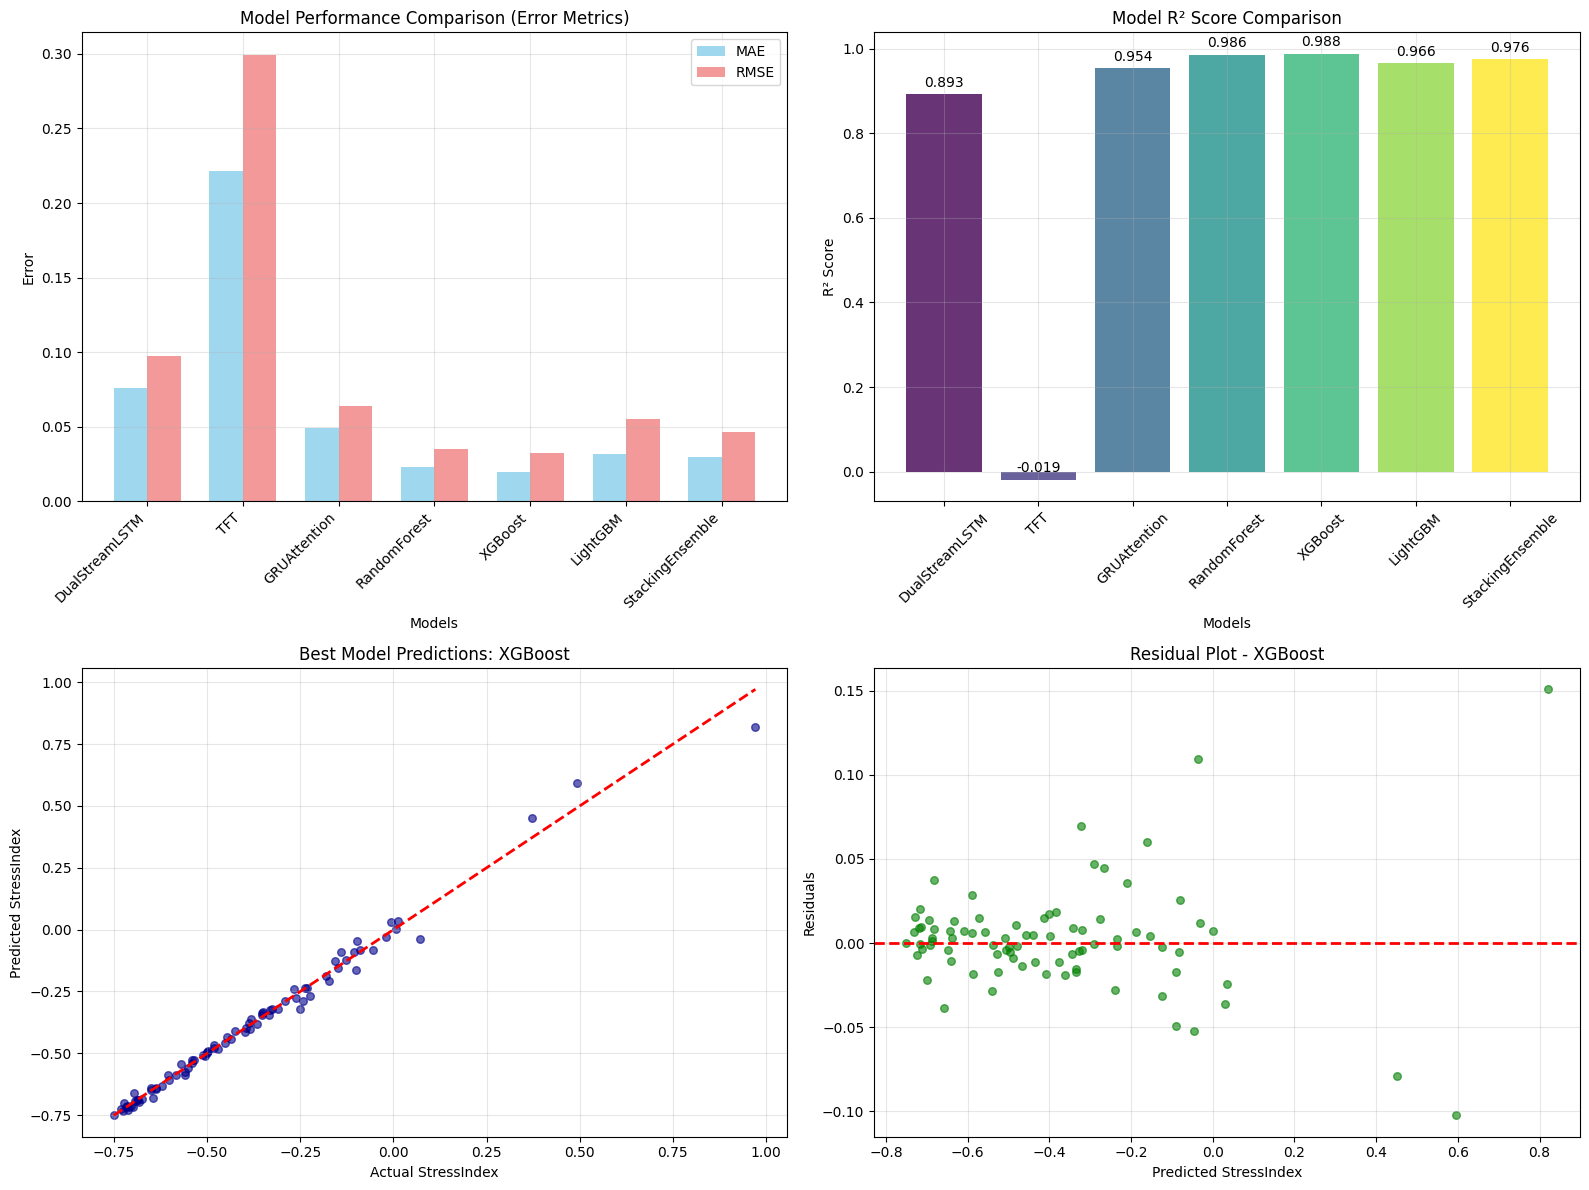

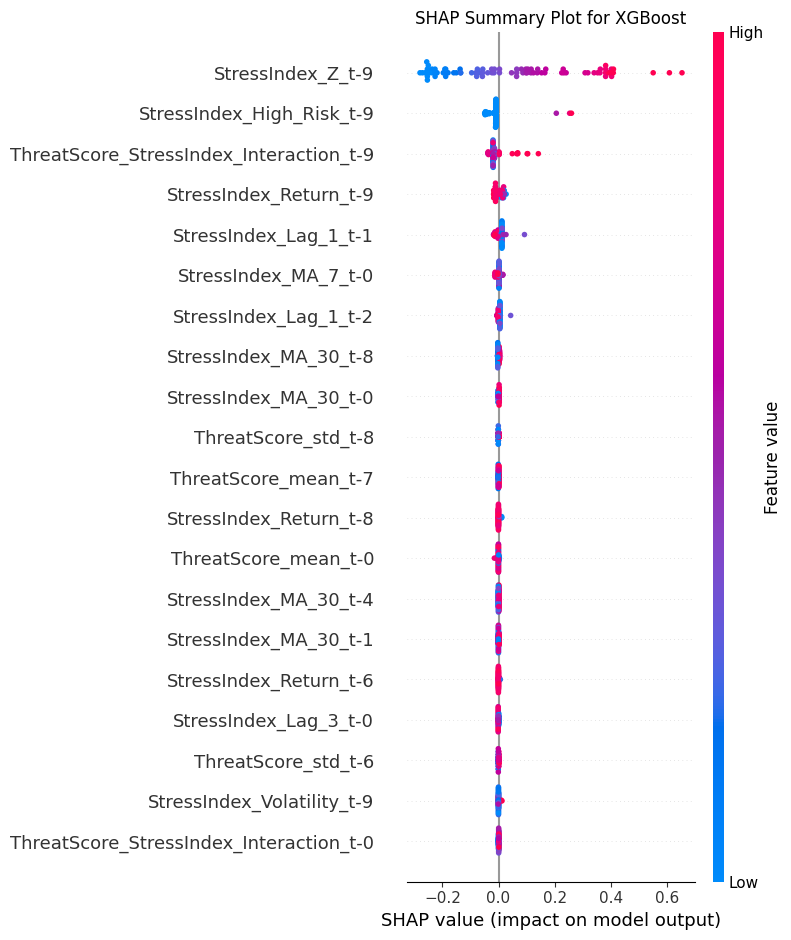

<Figure size 800x600 with 0 Axes>

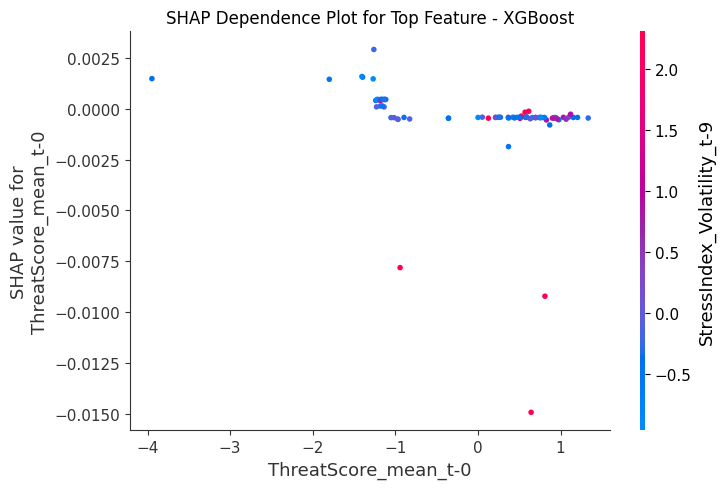

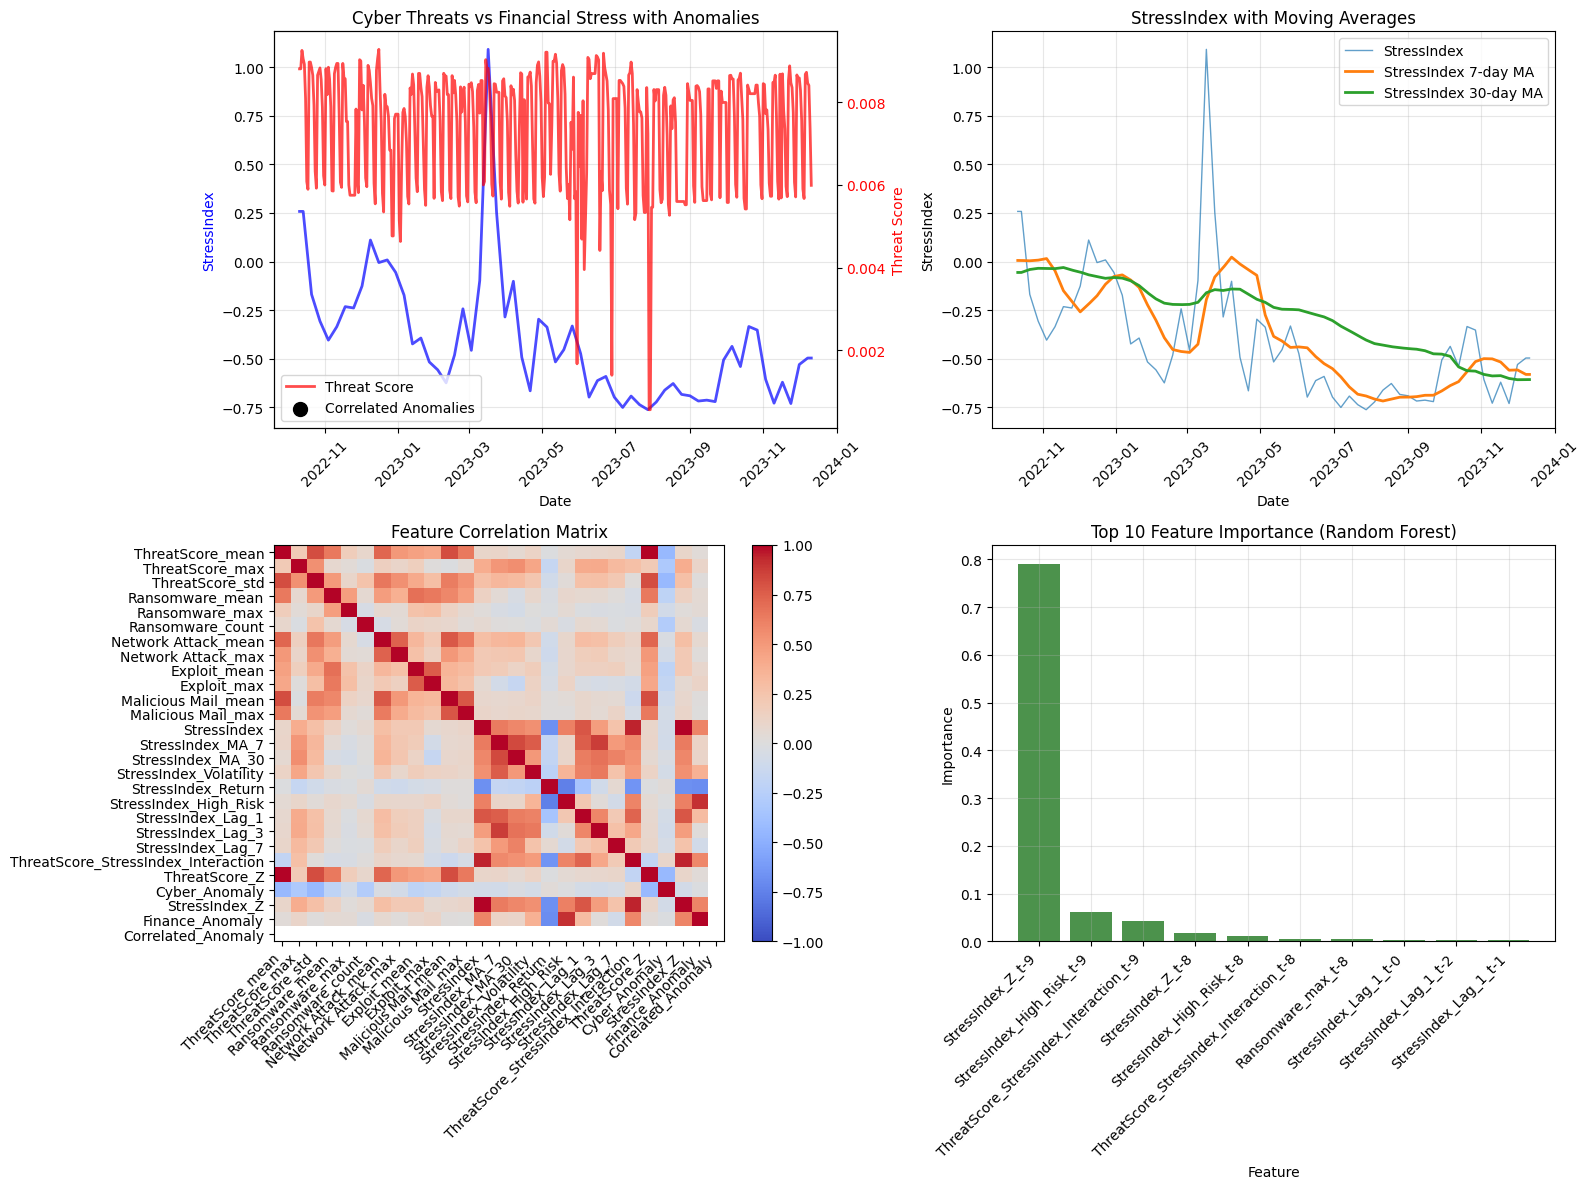

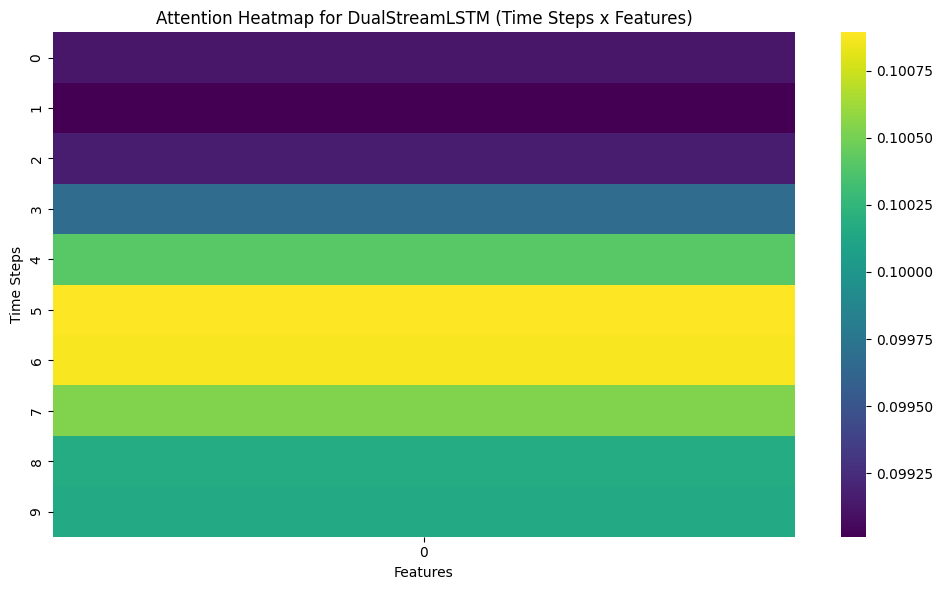

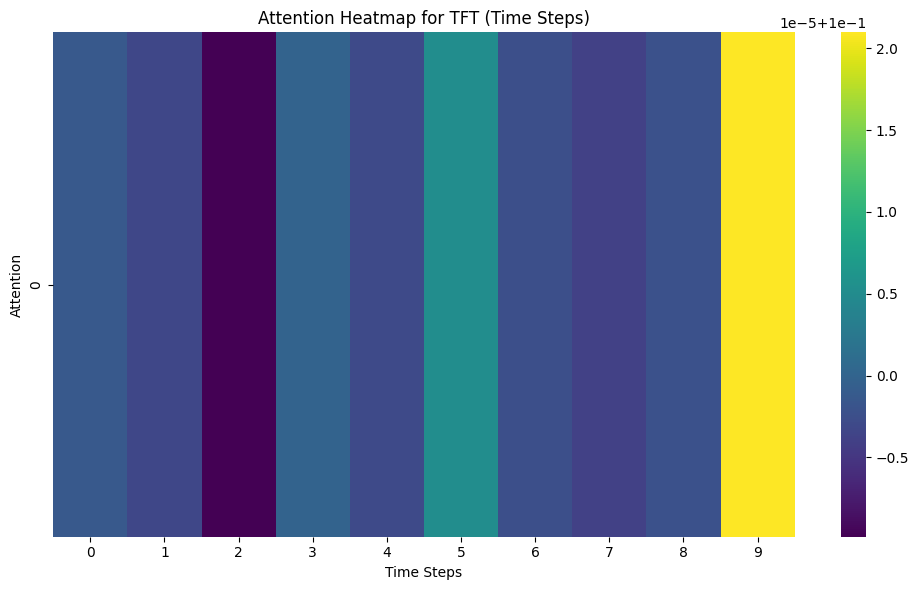

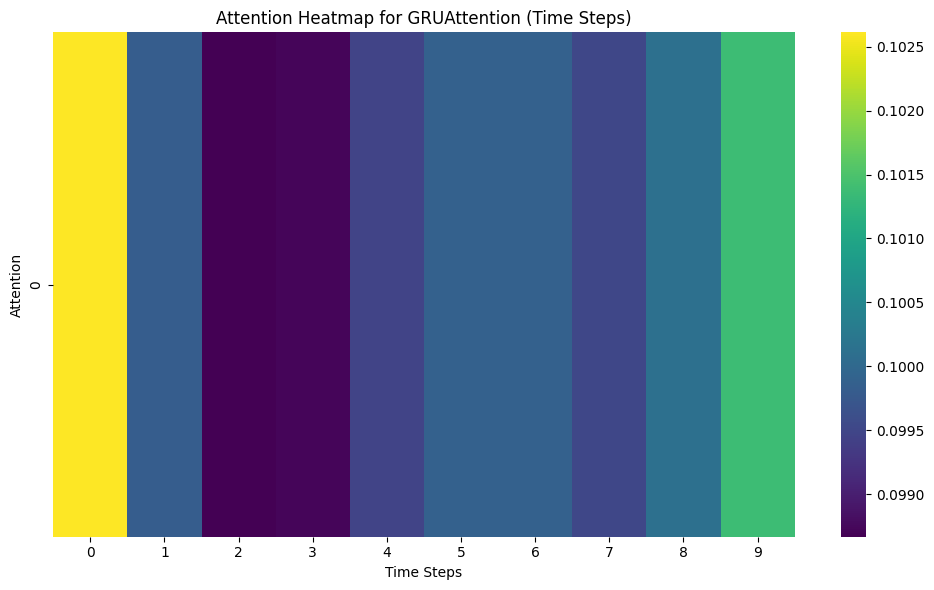


Best Model: XGBoost
Best RMSE: 0.0321
Analysis completed successfully!


In [17]:
if __name__ == "__main__":
    try:
        models, results, data = main()
        print("Analysis completed successfully!")
    except Exception as e:
        print(f"Error occurred: {e}")
        import traceback
        traceback.print_exc()